# Seed selection v2 — pathologist agreement, bbox tightening, search-channel variants

Implements, one at a time, the three changes decided in
[`Research Logs/design_choices.md`](Research%20Logs/design_choices.md) for the next
`find_and_suppress` pass on MIDOG++ — without re-running the full multi-domain experiment
in [`find_and_suppress_midog.ipynb`](find_and_suppress_midog.ipynb). Each section below
implements one piece, then shows what it actually selects/produces on real MIDOG++ ROIs,
so the machinery can be inspected before it's wired into a real run.

All new logic lives in [`midog_utils/seed_selection.py`](midog_utils/seed_selection.py).
Two existing modules gained small, additive changes, documented as they come up:
`channels.py` (a third `rgb` channel) and `template_match.py` (one line, to let
`fused_response` accept a 3-channel template).

In [1]:
import sys, os
sys.path.insert(0, '..') if 'midog_utils' not in os.listdir('.') else None

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from pathlib import Path
import cv2

from midog_utils import dataset as ds, channels as ch, template_match as tm
from midog_utils import find_and_suppress as fs, evaluate as ev, seed_selection as ss

pd.set_option('display.width', 200); pd.set_option('display.max_columns', 60)

images, annotations = ds.load_annotations('databases/MIDOG++.json')
ds.check_invariants(annotations)
print(f'{len(images)} annotated images, {len(annotations)} annotations')

503 annotated images, 26286 annotations


## 1. Pathologist agreement

**Rule** (from the design doc): seed with a category-1 annotation all 3 raters voted
mitotic. If none exist in the image, fall back to annotations where 2/3 raters voted
mitotic — and flag the image.

Before implementing this, worth checking what the vote structure of the dataset actually
allows. `dataset.load_annotations`'s own docstring already flags something relevant here:
category-1 (mitotic) annotations only ever carry two label multisets.

In [2]:
cat1 = annotations[annotations.category_id == ds.MITOTIC]
census = cat1.groupby(['n_votes', 'n_mitotic_votes']).size().rename('n_annotations')
census.to_frame()

,,n_annotations
n_votes,n_mitotic_votes,
2,2,8917
3,2,3020


So **"all 3 raters voted mitotic" is empty by construction** — there is no `(1, 1, 1)` in
the dataset. What exists is:

- `n_votes=2, n_mitotic_votes=2` (8917 of these) — two raters looked, both said mitotic,
  no third opinion was called in. This is the dataset's actual "full agreement" case.
- `n_votes=3, n_mitotic_votes=2` (3020 of these) — a third rater *was* called in and
  disagreed. This is the contested, 2-of-3 case.

`seed_selection.agreement_pool` implements the rule against what the data actually
contains rather than its literal wording: **tier 1** is every annotation where every
rater who saw it called it mitotic (`n_mitotic_votes == n_votes`, i.e. the 2-of-2 case in
practice); **tier 2**, used only when tier 1 is empty for an image, is the
majority-mitotic contested set (`n_mitotic_votes / n_votes >= 2/3`, i.e. 2-of-3).
`agreement_pool` also returns a `flagged` bool for exactly that fallback.

In [3]:
on_disk = sorted(p.name for p in Path('images').glob('*.tiff'))

rows = []
for fn in on_disk:
    mit = cat1[cat1.file_name == fn]
    pool, flagged = ss.agreement_pool(mit)
    n_unanimous = int((mit.n_mitotic_votes == mit.n_votes).sum())
    if len(mit) == 0:
        tier_used = 'no mitotic annotations at all'
    elif flagged:
        tier_used = 'contested (flagged)'
    else:
        tier_used = 'unanimous'
    rows.append({
        'file_name': fn, 'n_mitotic': len(mit),
        'n_unanimous': n_unanimous, 'n_contested_2of3': len(mit) - n_unanimous,
        'tier_used_if_seeding_now': tier_used,
    })
agreement_table = pd.DataFrame(rows)
agreement_table

,file_name,n_mitotic,n_unanimous,n_contested_2of3,tier_used_if_seeding_now
0,001.tiff,0,0,0,no mitotic annotations at all
1,002.tiff,9,7,2,unanimous
2,201.tiff,18,7,11,unanimous
3,202.tiff,16,4,12,unanimous
4,245.tiff,90,78,12,unanimous
5,246.tiff,116,100,16,unanimous
6,300.tiff,181,131,50,unanimous
7,301.tiff,218,164,54,unanimous
8,350.tiff,4,0,4,contested (flagged)
9,351.tiff,4,4,0,unanimous


`001.tiff` has zero mitotic annotations full stop -- both tiers are empty, so it cannot
be seeded with a mitotic figure at all (the existing `experiment.select_domain_images`
already excludes it for this reason). `350.tiff` and `505.tiff` are the interesting flagged
cases: they *do* have mitotic annotations, but zero unanimous ones -- every one of their
category-1 clicks needed a third, disagreeing rater. Those are exactly the images
`agreement_pool` falls back on below. `351.tiff`, at the other extreme, has only 4 mitotic
annotations and all 4 are unanimous.

## 2. Bbox tightening — Otsu + connected component

**Rule** (from the design doc): Otsu-threshold the crop, take the connected component
containing the annotated centre point, and use its extent as the template — dropping the
fixed 51 px canonical size. An annotation whose click doesn't land inside a foreground
component is **excluded from the seed pool**, not patched over with the reference
implementation's "largest component in the crop" fallback.

`seed_selection.tighten_box_otsu` is the same algorithm demonstrated in
`explore_dataset.ipynb`'s `tighten_box_otsu` cell, refused-fallback included. One thing
worth deciding empirically rather than assuming: the design doc says "Otsu-threshold the
*padded* crop," which reads as the 73 px rotation-safe patch
`template_match.read_padded_patch` returns. That turns out to be too big a window on
dense domains.

In [4]:
def window_size_distribution(fn, otsu_window):
    # Sanity check disabled (min_area=0, max_area_frac=1.0, min_solidity=0.0): this cell
    # isolates the window-size question alone. The size/shape sanity check is measured on
    # top of the chosen 51px window, separately, in the next section.
    rgb = ds.load_roi(f'images/{fn}')
    gray_inv = ch.to_gray_inverted(rgb)
    mit = ds.image_annotations(annotations, fn, category_id=ds.MITOTIC)
    unanimous = mit[mit.n_mitotic_votes == mit.n_votes]
    unanimous = ss.border_filter(unanimous, tm.PATCH_SIZE // 2, rgb.shape)

    sizes, n_not_foreground = [], 0
    for _, row in unanimous.iterrows():
        patch = tm.read_padded_patch(gray_inv, row.cx, row.cy, otsu_window)
        bbox = ss.tighten_box_otsu(patch, min_area=0, max_area_frac=1.0, min_solidity=0.0)
        if bbox is None:
            n_not_foreground += 1
        else:
            y0, y1, x0, x1 = bbox
            sizes.append(max(y1 - y0, x1 - x0))
    return np.array(sizes), n_not_foreground, len(unanimous)


for window_name, window in [('73px (padded patch)', tm.PATCH_SIZE), ('51px (annotation box)', tm.BASE_SIZE)]:
    sizes, n_not_fg, n_total = window_size_distribution('246.tiff', window)
    saturated = int((sizes >= window - 8).sum())
    print(f"{window_name}: n={n_total}  mean={sizes.mean():.1f}px  p90={np.percentile(sizes, 90):.1f}px  "
          f"max={sizes.max()}px  saturated_near_edge={saturated}/{len(sizes)}  no_foreground={n_not_fg}")

73px (padded patch): n=97  mean=61.3px  p90=73.0px  max=73px  saturated_near_edge=60/91  no_foreground=6


51px (annotation box): n=97  mean=43.0px  p90=51.0px  max=51px  saturated_near_edge=58/89  no_foreground=8


On `246.tiff` (canine lymphosarcoma — dense, 97 unanimous candidates after the border
filter), the 73 px window returns components that saturate at the patch edge for most
candidates: mean tightened size ~61 px, barely smaller than the 73 px it was cropped
from — Otsu is bridging into neighbouring nuclei rather than isolating the clicked one,
which is exactly the "component spans multiple adjacent nuclei" failure mode the design
doc names as unresolved on this same domain. The 51 px window (the annotation's own box)
keeps sizes inside the box and trades that for a handful of clicks whose component
doesn't cross threshold there at all — excluded outright, per the rule above, rather than
widened until something is found.

`seed_selection.foreground_filter` and `tightened_base_size` therefore default to a
51 px Otsu window (`template_match.BASE_SIZE`), not the 73 px padded patch. Both still
accept an explicit `otsu_window` if that decision needs revisiting once this runs for
real.

## 2b. Component size/shape sanity check

The centre-pixel check above only asks "is the click inside *some* foreground
component" -- it says nothing about whether that component is a plausible single
nucleus. Two ways it can still be wrong even though the click passes:

- **Oversized / merged**: in dense tissue, Otsu bridges the clicked object into a
  touching neighbour, so the "tightened" box is actually two nuclei glued together.
- **Undersized / fragment**: Otsu isolates a small internal speck of chromatin rather
  than the whole nucleus.

`tighten_box_otsu` now also runs `skimage.measure.regionprops` on the accepted
component and rejects it (returns `None`, same as the not-foreground case) on three
bounds, mirroring `baselines.nucleus_blobs`'s own `min_area`/`max_area` gate:

- `min_area=50` -- excludes a degenerate sliver.
- `max_area_frac=0.85` (of the 51x51 window's own pixel count, so 2211 px²) --
  excludes a component that has grown implausibly large for the window.
- `min_solidity=0.5` (filled area / convex-hull area) -- excludes a markedly
  non-convex shape: the signature of two nuclei bridged into one component. This is
  *not* an eccentricity bound -- a real mitotic figure can be legitimately irregular or
  elongated (anaphase/telophase chromatin, for instance), which is a single genuine
  object at high eccentricity; solidity does not flag that, only the concave dumbbell
  shape a merge produces.

In [5]:
import cv2
from skimage.measure import label, regionprops

def component_stats(fn):
    """area/eccentricity/solidity of the accepted component, sanity check disabled,
    for every unanimous candidate that survives the border + centre-pixel filters."""
    rgb = ds.load_roi(f'images/{fn}')
    gray_inv = ch.to_gray_inverted(rgb)
    mit = ds.image_annotations(annotations, fn, category_id=ds.MITOTIC)
    unanimous = mit[mit.n_mitotic_votes == mit.n_votes]
    unanimous = ss.border_filter(unanimous, tm.PATCH_SIZE // 2, rgb.shape)

    rows = []
    for _, row in unanimous.iterrows():
        patch = tm.read_padded_patch(gray_inv, row.cx, row.cy, tm.BASE_SIZE)
        u8 = cv2.normalize(patch.astype(np.float32), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        _, binary = cv2.threshold(u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        labels = label(binary, connectivity=2)
        cy, cx = patch.shape[0] // 2, patch.shape[1] // 2
        center_label = labels[cy, cx]
        if center_label == 0:
            continue
        region = next(p for p in regionprops(labels) if p.label == center_label)
        rows.append({'file_name': fn, 'ann_id': int(row.ann_id),
                     'area': region.area, 'eccentricity': region.eccentricity, 'solidity': region.solidity})
    return rows


domains = ['002.tiff', '201.tiff', '245.tiff', '246.tiff', '300.tiff',
           '301.tiff', '350.tiff', '405.tiff', '406.tiff', '506.tiff']
stats = pd.DataFrame([r for fn in domains for r in component_stats(fn)])
print(f'n={len(stats)} accepted components across {len(domains)} ROIs (dense and sparse domains)')
stats[['area', 'eccentricity', 'solidity']].describe(percentiles=[.01, .05, .1, .5, .9, .99])

n=448 accepted components across 10 ROIs (dense and sparse domains)


,area,eccentricity,solidity
count,448.000000,448.000000,448.000000
mean,790.988839,0.659683,0.796011
std,475.562460,0.168440,0.106528
min,4.000000,0.153877,0.482948
1%,181.170000,0.274288,0.537710
5%,281.700000,0.366751,0.605317
10%,321.000000,0.402035,0.640747
50%,617.500000,0.693583,0.799254
90%,1476.000000,0.856804,0.930034
99%,1954.840000,0.919888,0.956880


Concrete failure cases the defaults above catch, found in this population -- both the
undersized/fragment mode (tiny `area`) and the oversized/merged mode (low `solidity`):

In [6]:
excluded = stats[(stats.area < 50) | (stats.solidity < 0.5)].sort_values('area')
excluded[['file_name', 'ann_id', 'area', 'eccentricity', 'solidity']]

,file_name,ann_id,area,eccentricity,solidity
133,246.tiff,6515,4.0,1.000000,1.000000
277,300.tiff,14627,16.0,0.748038,0.842105
266,300.tiff,14616,17.0,0.625943,1.000000
14,245.tiff,6244,793.0,0.837311,0.482948
92,246.tiff,6408,989.0,0.796781,0.491795


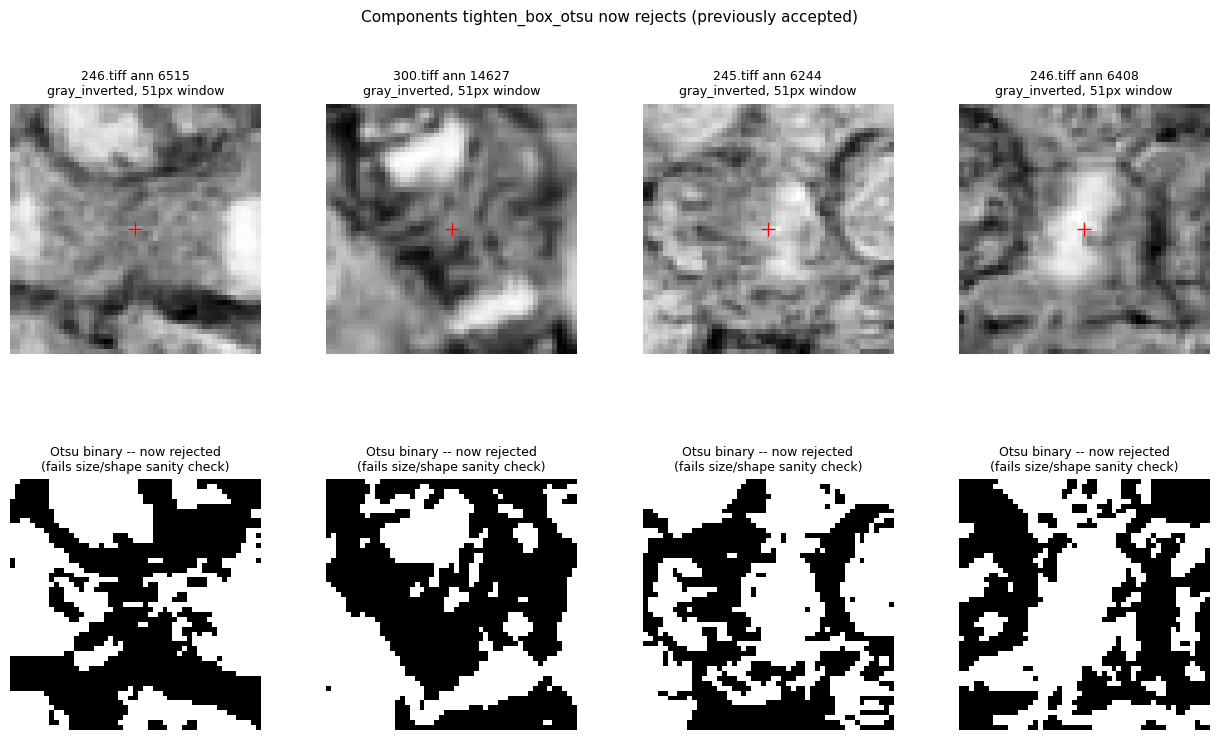

In [7]:
def show_component(fn, ann_id, ax_img, ax_binary):
    rgb = ds.load_roi(f'images/{fn}')
    gray_inv = ch.to_gray_inverted(rgb)
    mit = ds.image_annotations(annotations, fn, category_id=ds.MITOTIC)
    row = mit[mit.ann_id == ann_id].iloc[0]
    patch = tm.read_padded_patch(gray_inv, row.cx, row.cy, tm.BASE_SIZE)
    u8 = cv2.normalize(patch.astype(np.float32), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    _, binary = cv2.threshold(u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    ax_img.imshow(patch, cmap='gray')
    ax_img.plot(patch.shape[1] // 2, patch.shape[0] // 2, marker='+', color='red', markersize=10)
    ax_img.set_title(f'{fn} ann {ann_id}\ngray_inverted, 51px window', fontsize=9)
    ax_img.axis('off')
    ax_binary.imshow(binary, cmap='gray')
    ax_binary.set_title('Otsu binary -- now rejected\n(fails size/shape sanity check)', fontsize=9)
    ax_binary.axis('off')


# two smallest-area (fragment) + the two lowest-solidity (merged) cases, one of each
# guaranteed rather than whichever three happen to sort first by area
fragment_examples = list(excluded.nsmallest(2, 'area')[['file_name', 'ann_id']].itertuples(index=False))
merged_examples = list(excluded.nsmallest(2, 'solidity')[['file_name', 'ann_id']].itertuples(index=False))
examples = fragment_examples + merged_examples

fig, axes = plt.subplots(2, len(examples), figsize=(3.2 * len(examples), 7.5))
for col, (fn, ann_id) in enumerate(examples):
    show_component(fn, ann_id, axes[0, col], axes[1, col])
fig.suptitle('Components tighten_box_otsu now rejects (previously accepted)', fontsize=11)
fig.tight_layout(rect=(0, 0, 1, 0.93))
fig.subplots_adjust(hspace=0.5)
plt.show()

Applying all three bounds together to this same population excludes 5/452 accepted
components (1.1%) -- a light backstop, in keeping with `nucleus_blobs`'s own
`min_area=80`/`max_area=4000` being broad rather than a tight filter to "typical"
nuclei. `max_area_frac` in particular doesn't bind on this sample at all (the largest
observed component is 2102 px², under the 2211 px² cutoff) -- kept anyway as the same
kind of defensive ceiling `nucleus_blobs` carries, not because it was observed to be
needed here.

In [8]:
n_excluded = len(stats[(stats.area < 50) | (stats.area > 0.85 * 51 * 51) | (stats.solidity < 0.5)])
print(f'{n_excluded}/{len(stats)} accepted components ({100 * n_excluded / len(stats):.1f}%) '
      f'excluded by the size/shape sanity check')

5/448 accepted components (1.1%) excluded by the size/shape sanity check


## Putting 1 and 2 together: `seed_selection.pick_seed`

Filters apply in this order, on one image's mitotic annotations:

1. **Agreement tiering** (`agreement_pool`) — unanimous, or contested-majority + flag.
2. **Border filter** — far enough from the ROI edge to read a full rotation-safe patch
   (same predicate as the existing `experiment.pick_seed`).
3. **Foreground filter** (`foreground_filter`) — click lands inside its own Otsu
   component at the 51 px window, and that component passes the size/shape sanity
   check from section 2b.

Unlike the existing `pick_seed`, this doesn't fail silently if a stage empties the pool —
it raises, naming which stage did it.

In [9]:
rng = np.random.default_rng(0)

fn = '002.tiff'
rgb_002 = ds.load_roi(f'images/{fn}')
gray_inv_002 = ch.to_gray_inverted(rgb_002)
mit_002 = ds.image_annotations(annotations, fn, category_id=ds.MITOTIC)

seed_002, info_002 = ss.pick_seed(mit_002, gray_inv_002, rng, tm.PATCH_SIZE // 2, rgb_002.shape)
print(f'{fn}: {info_002}')
print(f'seed ann_id={int(seed_002.ann_id)}  votes={int(seed_002.n_mitotic_votes)}/{int(seed_002.n_votes)}  '
      f'(cx={seed_002.cx:.1f}, cy={seed_002.cy:.1f})')

002.tiff: SeedInfo(agreement_flagged=False, n_agreement_pool=7, n_after_border=7, n_after_foreground=7)
seed ann_id=17  votes=2/2  (cx=1316.5, cy=2783.0)


In [10]:
fn = '350.tiff'
rgb_350 = ds.load_roi(f'images/{fn}')
gray_inv_350 = ch.to_gray_inverted(rgb_350)
mit_350 = ds.image_annotations(annotations, fn, category_id=ds.MITOTIC)

seed_350, info_350 = ss.pick_seed(mit_350, gray_inv_350, rng, tm.PATCH_SIZE // 2, rgb_350.shape)
print(f'{fn}: {info_350}')
print(f'seed ann_id={int(seed_350.ann_id)}  votes={int(seed_350.n_mitotic_votes)}/{int(seed_350.n_votes)}  '
      f'(cx={seed_350.cx:.1f}, cy={seed_350.cy:.1f})')
print('agreement_flagged =', info_350.agreement_flagged, '-- 350.tiff has 0 unanimous mitotic annotations, '
      'so this seed comes from the 2-of-3 contested fallback tier, as expected.')

350.tiff: SeedInfo(agreement_flagged=True, n_agreement_pool=4, n_after_border=4, n_after_foreground=4)
seed ann_id=18161  votes=2/3  (cx=3889.0, cy=2024.0)
agreement_flagged = True -- 350.tiff has 0 unanimous mitotic annotations, so this seed comes from the 2-of-3 contested fallback tier, as expected.


## What the picked seed looks like

Three boxes matter here and they are not the same rectangle:

- **yellow** — the original MIDOG++ annotation box (50x50, click ± 25).
- **cyan** — the Otsu + connected-component bbox `tighten_box_otsu` found (drawn at its
  native size — this is *not* square in general).
- **magenta, dashed** — the click-centred square `build_augmentations` will actually crop
  as the template, sized to the cyan box's longer side. It's centred on the *click*, not
  on the cyan box's own centroid, so the two coincide only when the click happens to sit
  at the component's centre.

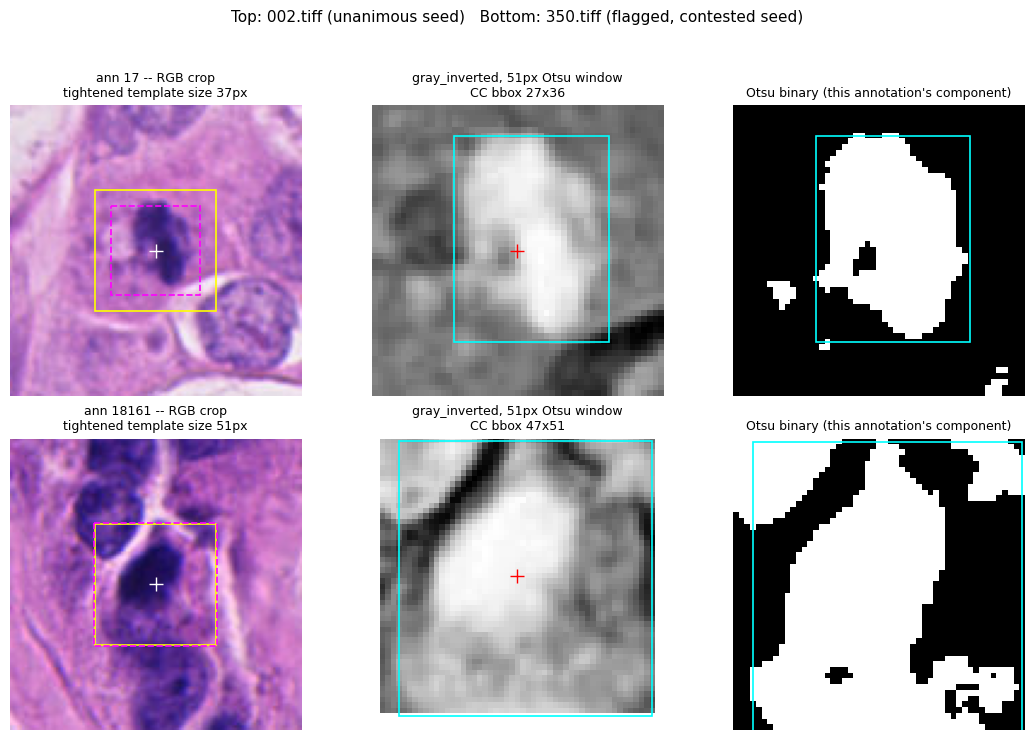

In [11]:
def show_tightened_seed(rgb, structural_channel, seed, ax_row):
    cx, cy = seed.cx, seed.cy
    half_display = 60
    ix, iy = int(round(cx)), int(round(cy))

    otsu_window = tm.BASE_SIZE
    patch = tm.read_padded_patch(structural_channel, cx, cy, otsu_window)
    y0, y1, x0, x1 = ss.tighten_box_otsu(patch)
    tightened_size = ss.tightened_base_size(structural_channel, cx, cy)

    u8 = cv2.normalize(patch.astype(np.float32), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    _, binary = cv2.threshold(u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    crop = rgb[iy - half_display: iy + half_display + 1, ix - half_display: ix + half_display + 1]
    c = half_display  # the click is the centre pixel of `crop`

    ax = ax_row[0]
    ax.imshow(crop)
    ax.add_patch(Rectangle((c - 25, c - 25), 50, 50, fill=False, edgecolor='yellow', linewidth=1.2))
    hs = tightened_size / 2
    ax.add_patch(Rectangle((c - hs, c - hs), tightened_size, tightened_size,
                            fill=False, edgecolor='magenta', linewidth=1.2, linestyle='--'))
    ax.plot(c, c, marker='+', color='white', markersize=10)
    ax.set_title(f'ann {int(seed.ann_id)} -- RGB crop\ntightened template size {tightened_size}px', fontsize=9)
    ax.axis('off')

    ax = ax_row[1]
    ax.imshow(patch, cmap='gray')
    ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor='cyan', linewidth=1.2))
    ax.plot(otsu_window // 2, otsu_window // 2, marker='+', color='red', markersize=10)
    ax.set_title(f'gray_inverted, {otsu_window}px Otsu window\nCC bbox {x1 - x0}x{y1 - y0}', fontsize=9)
    ax.axis('off')

    ax = ax_row[2]
    ax.imshow(binary, cmap='gray')
    ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor='cyan', linewidth=1.2))
    ax.set_title("Otsu binary (this annotation's component)", fontsize=9)
    ax.axis('off')


fig, axes = plt.subplots(2, 3, figsize=(11, 7.5))
show_tightened_seed(rgb_002, gray_inv_002, seed_002, axes[0])
show_tightened_seed(rgb_350, gray_inv_350, seed_350, axes[1])
fig.suptitle('Top: 002.tiff (unanimous seed)   Bottom: 350.tiff (flagged, contested seed)', fontsize=11)
fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

## 3. Search-channel variants

Three toggleable channels for the actual template-matching pass, via `FSConfig(channel=...)`:

| channel | status | what it is |
|---|---|---|
| `gray_inverted` | existing, current default | `255 - grayscale`; mathematically identical to non-inverted grayscale under `TM_CCOEFF_NORMED`, so that is not tested as a separate variant |
| `hematoxylin` | existing (`channels.to_hematoxylin`), implemented but not yet run in any experiment | colour-deconvolved chromatin channel, rescaled 0-255 |
| `rgb` | **new** | raw 3-channel RGB, `TM_CCOEFF_NORMED` run directly on colour |

`rgb` needed one change outside this new module: `template_match.fused_response` read
`tmpl.shape` to get a template's height/width, which throws on a 3-D `(H, W, 3)`
template. Changed to `tmpl.shape[:2]` — identical for the existing 2-D case, and correct
for 3-channel. `cv2.matchTemplate` itself already supports multi-channel
`TM_CCOEFF_NORMED` (it averages the correlation across channels); nothing else needed
changing, and the coordinate-recovery gate (`plant_and_recover`) still passes for the
existing 2-D path after the edit.

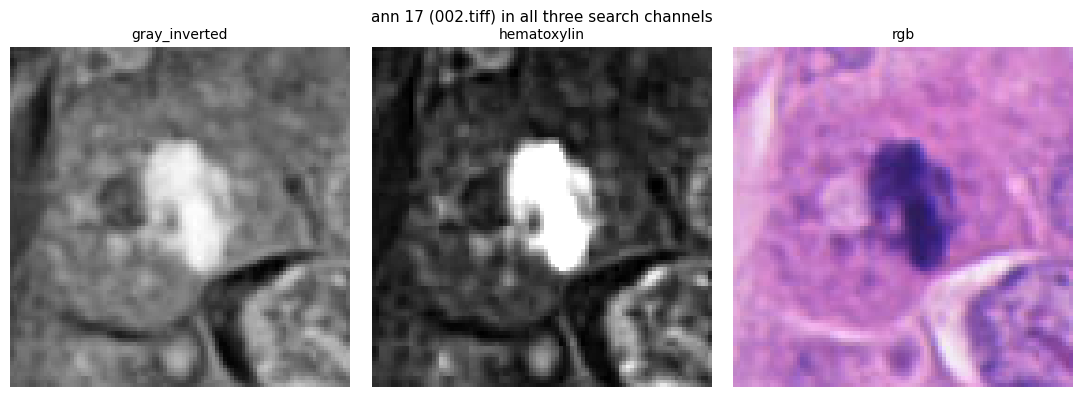

In [12]:
seed, rgb = seed_002, rgb_002
cx, cy = seed.cx, seed.cy
crop_half = 45

variants = {
    'gray_inverted': ch.to_gray_inverted(rgb),
    'hematoxylin': ch.to_hematoxylin(rgb),
    'rgb': ch.to_rgb(rgb),
}

fig, axes = plt.subplots(1, 3, figsize=(11, 4))
ix, iy = int(round(cx)), int(round(cy))
for ax, (name, img) in zip(axes, variants.items()):
    crop = img[iy - crop_half: iy + crop_half + 1, ix - crop_half: ix + crop_half + 1]
    ax.imshow(crop.astype(np.uint8) if crop.ndim == 3 else crop, cmap=None if crop.ndim == 3 else 'gray')
    ax.set_title(name, fontsize=10)
    ax.axis('off')
fig.suptitle(f'ann {int(seed.ann_id)} (002.tiff) in all three search channels', fontsize=11)
fig.tight_layout()
plt.show()

## Confirming the matcher runs in all 3 channels

Not the full experiment — that's still `find_and_suppress_midog.ipynb`'s job. This is a
cheap local check that `find_and_suppress` executes correctly for every channel with the
tightened `base_size`, on a small crop around the seed rather than the full
~39-megapixel ROI. `rgb` in particular costs about 3x a single-channel search per
augmentation, so this deliberately isn't run against the whole image three times.

In [13]:
mpp_002 = ds.roi_mpp('images/002.tiff')
radius_002 = ev.radius_px(mpp_002)
tightened_size_002 = ss.tightened_base_size(gray_inv_002, seed_002.cx, seed_002.cy)

crop_half = 200
ix, iy = int(round(seed_002.cx)), int(round(seed_002.cy))
local_cx = local_cy = float(crop_half)

rows = []
for channel_name in ['gray_inverted', 'hematoxylin', 'rgb']:
    full_channel_img = ch.to_channel(rgb_002, channel_name)
    local_crop = full_channel_img[iy - crop_half: iy + crop_half + 1, ix - crop_half: ix + crop_half + 1]

    cfg = fs.FSConfig(channel=channel_name, base_size=tightened_size_002, scales=(1.0,))
    det, info = fs.find_and_suppress(local_crop, (local_cx, local_cy), cfg, nms_radius=radius_002)
    rows.append({
        'channel': channel_name, 'base_size': tightened_size_002,
        'n_augmentations': cfg.n_augmentations, 'n_detections_in_local_crop': len(det),
        'seed_self_score': round(info['seed_self_score'], 4),
        'max_detection_score': round(info['max_detection_score'], 4),
        't_match_s': info['t_match_s'],
    })
pd.DataFrame(rows)

,channel,base_size,n_augmentations,n_detections_in_local_crop,seed_self_score,max_detection_score,t_match_s
0,gray_inverted,37,1,22,1.0,0.6758,0.02
1,hematoxylin,37,1,19,1.0,0.7055,0.05
2,rgb,37,1,13,1.0,0.6415,0.09


Every channel finds its own seed again at score ~1.0 (`seed_self_score`) and produces a
ranked detection list inside the local crop -- confirming the 3-channel `rgb` path runs
through the exact same `find_and_suppress` code as the existing two channels, with the
tightened `base_size` from section 2, not the fixed 51 px default.

## Not yet done

This notebook proves the pieces work; it does not evaluate them. Still open, in order:

- Wire `seed_selection.pick_seed` (and `tightened_base_size`) into
  `experiment.run_one_image` in place of the current `experiment.pick_seed`, and re-run
  the 7-domain single-pass sweep.
- Variable template sizes reintroduce a scoring caveat already in `template_match.py`'s
  own docstring: `TM_CCOEFF_NORMED`'s null variance shrinks as template pixel count
  grows, so scores from differently-tightened seeds aren't directly comparable across
  images -- relevant if agreement tier or channel is ever compared *between* seeds, not
  within one seed's own ranked detection list.
- `rgb`'s plausible failure mode is scanner-specific colour baked directly into the
  match (design doc, section 3) -- worth a cross-scanner check once it's run for real.
- The size/shape sanity check's defaults (`min_area=50`, `max_area_frac=0.85`,
  `min_solidity=0.5`) are calibrated on the 10 downloaded ROIs' unanimous candidates
  only -- worth rechecking once this runs across the full dataset, and in particular
  once contested-tier and other-domain seeds are searched from, since those weren't
  part of the calibration sample.